In [54]:
import os, yaml, sys
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from II_analyses.metrics_comparison import metric_comparison_save_name


In [83]:
from dataclasses import dataclass

@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    new_fs: int = 100
    ks: tuple = (1, 10, 50, 100) #, 200) #, 500)
    metric_A: str = "cosine_cnt"
    metric_B: str = "correlation"
    all_metrics: tuple = ("cosine", "cosine_cnt", "euclidean", "correlation") #, "magnitude_diff")
    results_dir: Path = Path(paths["data_path"]) / "results"
    subsamples_size=200
    iterations=20
    k_for_monkey_timecourse: int = 10
    monkey_sessions: tuple = (
        ("paul", "230204"),
        ("baby1", "220226to527"),
        ("three0", "250313"),
        ("red", "220227"),
        ("octavius", "220227to405"),
        ("friday", "220228to327"),
        ("baby5", "221104to24"),
    )

cfg = Cfg()
cfg


Cfg(monkey_name='three0', date='250313', brain_area='AIT', new_fs=100, ks=(1, 10, 50, 100), metric_A='cosine_cnt', metric_B='correlation', all_metrics=('cosine', 'cosine_cnt', 'euclidean', 'correlation'), results_dir=PosixPath('/Users/tizianocausin/metrics_II_local/results'), k_for_monkey_timecourse=10, monkey_sessions=(('paul', '230204'), ('baby1', '220226to527'), ('three0', '250313'), ('red', '220227'), ('octavius', '220227to405'), ('friday', '220228to327'), ('baby5', '221104to24')))

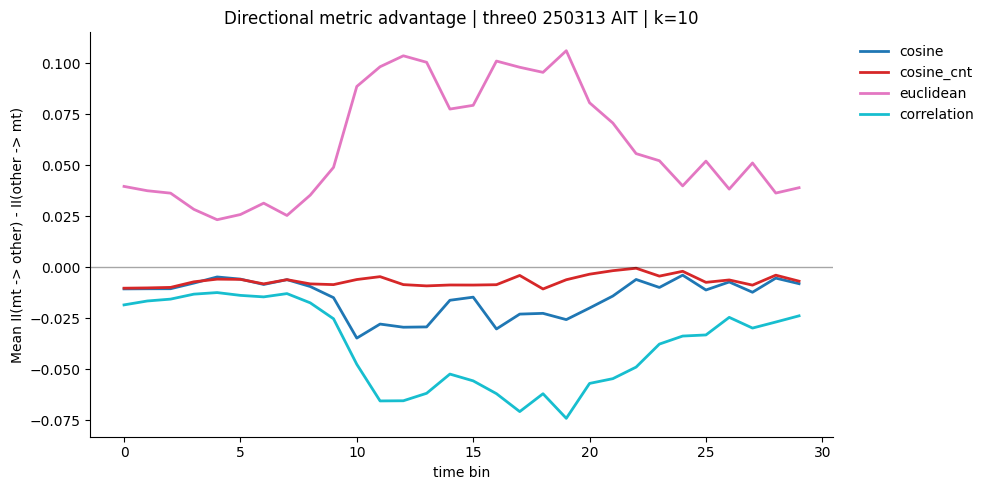

In [84]:
def metric_comparison_path(metric_from, metric_to, k, monkey_name=None, date=None, brain_area=None):
    return Path(
        metric_comparison_save_name(
            paths,
            metric_from,
            metric_to,
            k,
            cfg.monkey_name if monkey_name is None else monkey_name,
            cfg.date if date is None else date,
            cfg.brain_area if brain_area is None else brain_area,
            cfg.new_fs,
            subsamples_size=cfg.subsamples_size,
            n_iterations=cfg.iterations,
        )
    )


def load_metric_comparison_timecourse(metric_from, metric_to, k):
    fn = metric_comparison_path(metric_from, metric_to, k)
    if not fn.exists():
        raise FileNotFoundError(fn)
    return np.load(fn)["arr_0"]


k = cfg.k_for_monkey_timecourse
metric_advantage = {}
missing = []

for metric_A in cfg.all_metrics:
    pairwise_differences = []
    for metric_B in cfg.all_metrics:
        if metric_A == metric_B:
            continue
        try:
            A2B = load_metric_comparison_timecourse(metric_A, metric_B, k)
            B2A = load_metric_comparison_timecourse(metric_B, metric_A, k)
        except FileNotFoundError as err:
            missing.append(str(err))
            continue
        pairwise_differences.append(A2B - B2A)

    if pairwise_differences:
        metric_advantage[metric_A] = np.nanmean(np.stack(pairwise_differences), axis=0)

if not metric_advantage:
    for fn in missing:
        print(f"missing: {fn}")
    raise FileNotFoundError("No metric-comparison pairs found for the configured metrics")

n_time = len(next(iter(metric_advantage.values())))
time_bins = np.arange(n_time)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(cfg.all_metrics)))

for color, metric in zip(colors, cfg.all_metrics):
    if metric not in metric_advantage:
        continue
    ax.plot(
        time_bins,
        -metric_advantage[metric],
        linewidth=2,
        color=color,
        label=metric,
    )

ax.axhline(0, color="black", linewidth=1, alpha=0.35)
ax.set_xlabel("time bin")
ax.set_ylabel("Mean II(mt -> other) - II(other -> mt)")
ax.set_title(
    f"Directional metric advantage | {cfg.monkey_name} {cfg.date} {cfg.brain_area} | k={k}"
)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

if missing:
    print(f"Skipped {len(missing)} missing files")
    for fn in missing[:10]:
        print(f"missing: {fn}")


In [75]:
def metric_comparison_fn(metric_from, metric_to, k):
    return Path(
        metric_comparison_save_name(
            paths,
            metric_from,
            metric_to,
            k,
            cfg.monkey_name,
            cfg.date,
            cfg.brain_area,
            cfg.new_fs,
            subsamples_size=cfg.subsamples_size,
            n_iterations=cfg.iterations
        )
    )

def load_metric_comparison(metric_from, metric_to, k):
    fn = metric_comparison_fn(metric_from, metric_to, k)
    if not fn.exists():
        raise FileNotFoundError(fn)
    return np.load(fn)["arr_0"]


A2B = {}
B2A = {}
missing = []
for k in cfg.ks:
    for metric_from, metric_to, target in [
        (cfg.metric_A, cfg.metric_B, A2B),
        (cfg.metric_B, cfg.metric_A, B2A),
    ]:
        try:
            target[k] = load_metric_comparison(metric_from, metric_to, k)
        except FileNotFoundError:
            missing.append(metric_comparison_fn(metric_from, metric_to, k))

if missing:
    for fn in missing:
        print(f"missing: {fn}")
    raise FileNotFoundError(f"Missing {len(missing)} metric-comparison files")

n_time = len(next(iter(A2B.values())))
time_bins = np.arange(n_time)
print(f"loaded {len(cfg.ks)} k values; timecourse length = {n_time}")


loaded 4 k values; timecourse length = 30


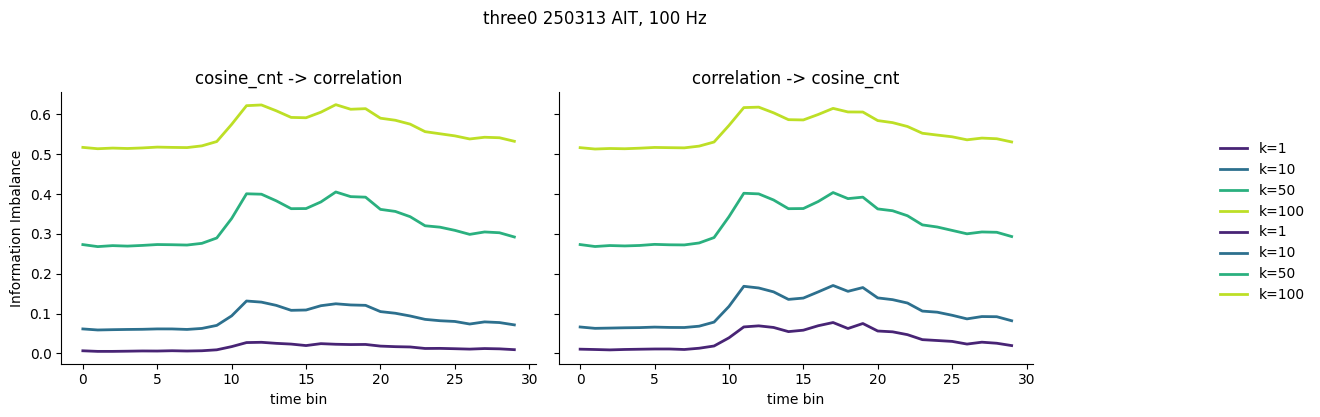

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(cfg.ks)))

for color, k in zip(colors, cfg.ks):
    ax[0].plot(time_bins, A2B[k], color=color, linewidth=2, label=f"k={k}")
    ax[1].plot(time_bins, B2A[k], color=color, linewidth=2, label=f"k={k}")

ax[0].set_title(f"{cfg.metric_A} -> {cfg.metric_B}")
ax[1].set_title(f"{cfg.metric_B} -> {cfg.metric_A}")
for a in ax:
    a.set_xlabel("time bin")
    a.spines[["top", "right"]].set_visible(False)
ax[0].set_ylabel("Information Imbalance")

fig.suptitle(
    f"{cfg.monkey_name} {cfg.date} {cfg.brain_area}, {cfg.new_fs} Hz",
    y=1.03,
)
fig.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.tight_layout(rect=[0, 0, 0.88, 1])


Text(0.5, 0.98, 'three0 250313 AIT, 100 Hz')

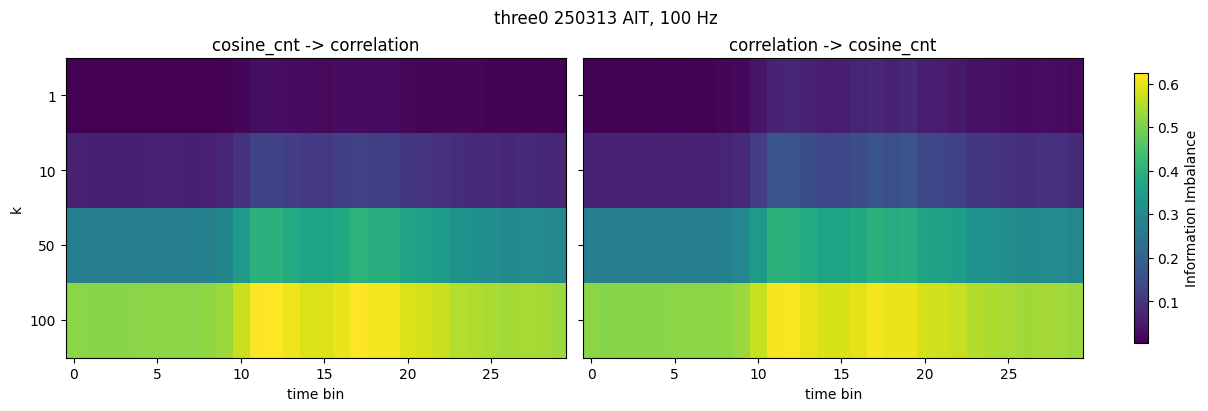

In [72]:
A2B_mat = np.stack([A2B[k] for k in cfg.ks])
B2A_mat = np.stack([B2A[k] for k in cfg.ks])
vmin = min(A2B_mat.min(), B2A_mat.min())
vmax = max(A2B_mat.max(), B2A_mat.max())

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True, constrained_layout=True)
for a, mat, title in [
    (ax[0], A2B_mat, f"{cfg.metric_A} -> {cfg.metric_B}"),
    (ax[1], B2A_mat, f"{cfg.metric_B} -> {cfg.metric_A}"),
]:
    im = a.imshow(mat, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax)
    a.set_title(title)
    a.set_xlabel("time bin")
    a.set_yticks(np.arange(len(cfg.ks)))
    a.set_yticklabels(cfg.ks)
ax[0].set_ylabel("k")

fig.colorbar(im, ax=ax, label="Information Imbalance", shrink=0.9)
fig.suptitle(f"{cfg.monkey_name} {cfg.date} {cfg.brain_area}, {cfg.new_fs} Hz")


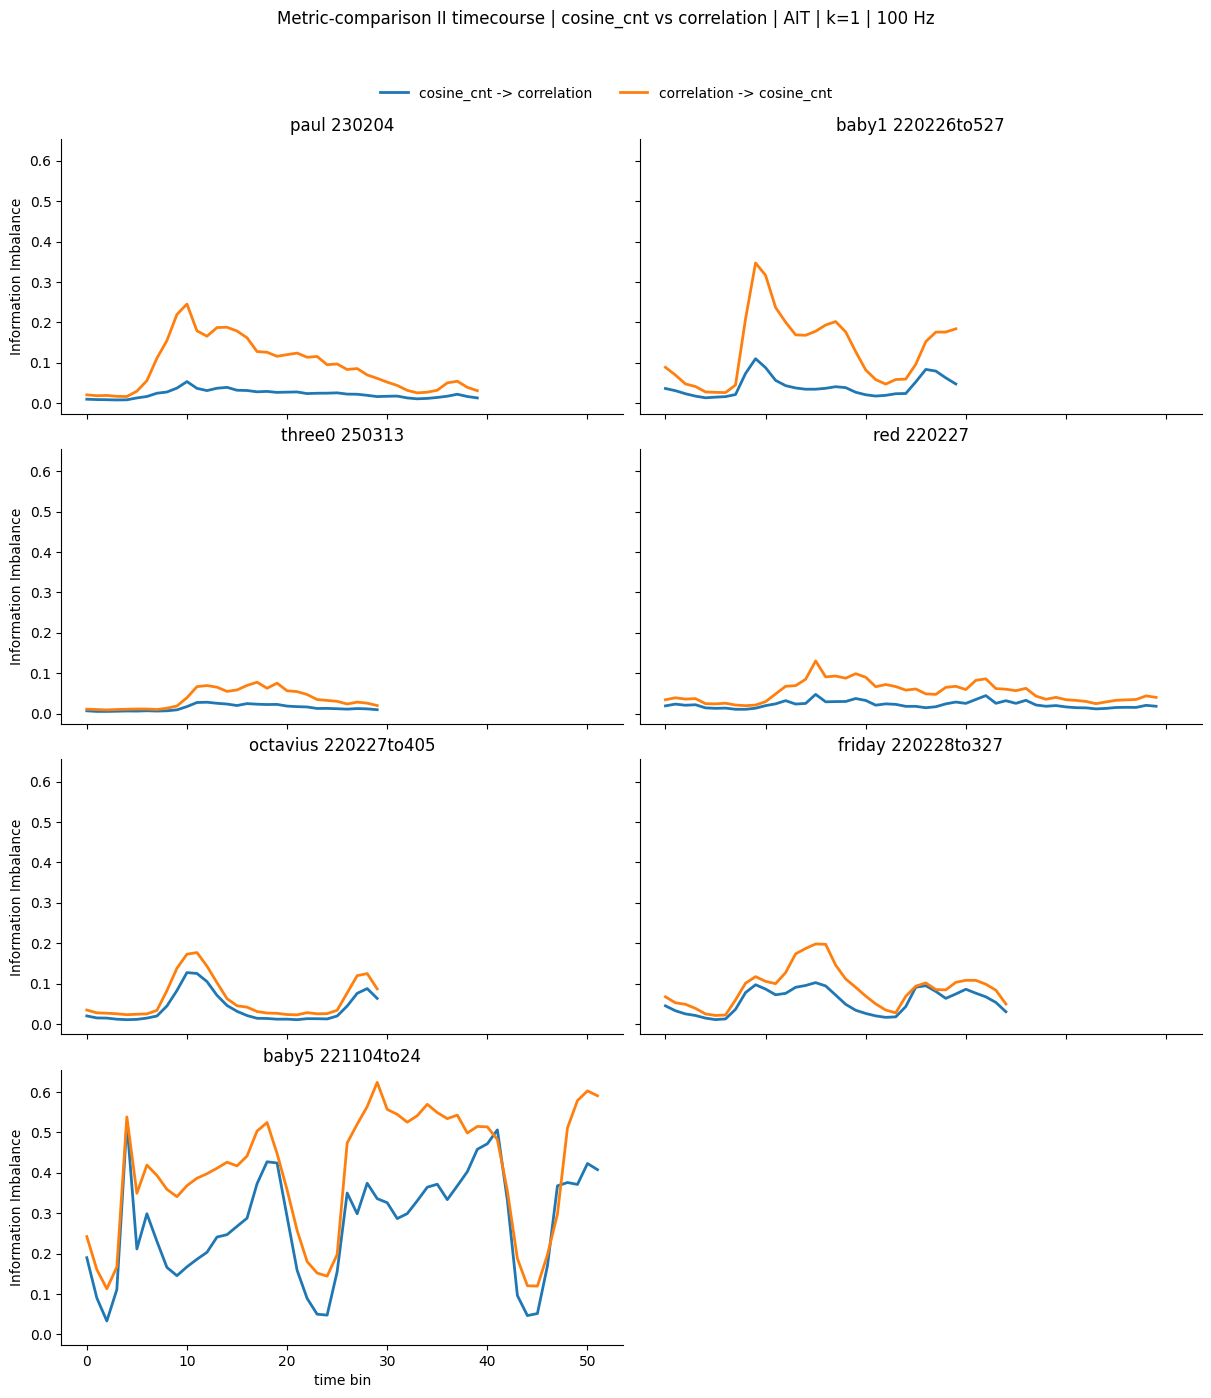

In [73]:
def metric_comparison_fn_for_session(metric_from, metric_to, k, monkey_name, date, brain_area=None):
    return Path(
        metric_comparison_save_name(
            paths,
            metric_from,
            metric_to,
            k,
            monkey_name,
            date,
            cfg.brain_area if brain_area is None else brain_area,
            cfg.new_fs,
            subsamples_size=cfg.subsamples_size,
            n_iterations=cfg.iterations,
        )
    )


def load_metric_comparison_for_session(metric_from, metric_to, k, monkey_name, date, brain_area=None):
    fn = metric_comparison_fn_for_session(metric_from, metric_to, k, monkey_name, date, brain_area)
    if not fn.exists():
        raise FileNotFoundError(fn)
    return np.load(fn)["arr_0"]


k = cfg.k_for_monkey_timecourse
monkey_timecourses = []
missing = []

for monkey_name, date in cfg.monkey_sessions:
    try:
        try:
            A2B_curve = load_metric_comparison_for_session(cfg.metric_A, cfg.metric_B, k, monkey_name, date)
            B2A_curve = load_metric_comparison_for_session(cfg.metric_B, cfg.metric_A, k, monkey_name, date)
        except:
            A2B_curve = load_metric_comparison_for_session(cfg.metric_A, cfg.metric_B, k, monkey_name, date, brain_area="CIT")
            B2A_curve = load_metric_comparison_for_session(cfg.metric_B, cfg.metric_A, k, monkey_name, date, brain_area="CIT")
    except FileNotFoundError as err:
        missing.append(str(err))
        continue

    monkey_timecourses.append((monkey_name, date, A2B_curve, B2A_curve))

if not monkey_timecourses:
    for fn in missing:
        print(f"missing: {fn}")
    raise FileNotFoundError("No metric-comparison files found for the configured monkey sessions")

n_cols = 2
n_rows = math.ceil(len(monkey_timecourses) / n_cols)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 3.2 * n_rows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, (monkey_name, date, A2B_curve, B2A_curve) in zip(axes, monkey_timecourses):
    time_bins = np.arange(len(A2B_curve))
    ax.plot(time_bins, A2B_curve, linewidth=2, label=f"{cfg.metric_A} -> {cfg.metric_B}")
    ax.plot(time_bins, B2A_curve, linewidth=2, label=f"{cfg.metric_B} -> {cfg.metric_A}")
    ax.set_title(f"{monkey_name} {date}")
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(monkey_timecourses):]:
    ax.set_visible(False)

for ax in axes[-n_cols:]:
    if ax.get_visible():
        ax.set_xlabel("time bin")
for ax in axes[::n_cols]:
    ax.set_ylabel("Information Imbalance")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.03), ncol=2, frameon=False)
fig.suptitle(
    f"Metric-comparison II timecourse | {cfg.metric_A} vs {cfg.metric_B} | {cfg.brain_area} | k={k} | {cfg.new_fs} Hz",
    y=1.08,
)

if missing:
    print(f"Skipped {len(missing)} missing files")
    for fn in missing[:10]:
        print(f"missing: {fn}")
